In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)

In [ ]:
full_data = pd.read_csv("/titanic_dataset.csv")

In [ ]:
# data shape
print('train data:', full_data.shape)

train data: (891, 12)


In [ ]:
# identify the categorical features
full_data.select_dtypes(include=['category']).columns

Index([], dtype='object')

In [ ]:
# convert categorical variable into 'dummy' or indicator variables
sex = pd.get_dummies(full_data['Sex'], drop_first=True)
embark = pd.get_dummies(full_data['Embarked'], drop_first=True)

In [ ]:
# view first few rows
full_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Add new dummy columns to data frame
full_data = pd.concat([full_data, sex, embark], axis=1)
full_data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,True,False,True


In [ ]:
# drop unnecessary columns
full_data.drop(['Sex', 'Embarked'], axis=1, inplace=True)

#shape of train data
print('train data:', full_data.shape)

# confirm changes
full_data.head()

train data: (891, 13)


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,True,False,True


In [ ]:
# identify the categorical features
full_data.select_dtypes(include=['category']).columns

Index([], dtype='object')

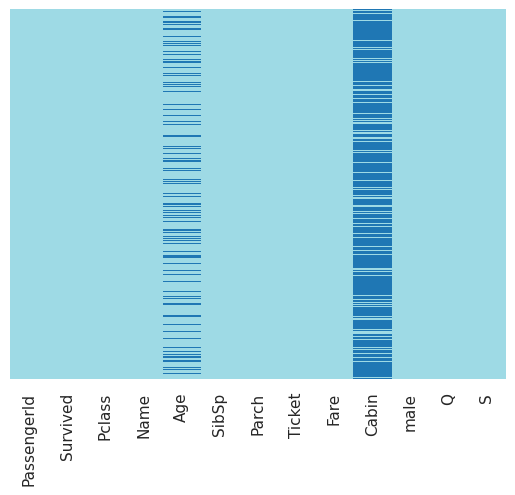

In [ ]:
# heatmap
sns.heatmap(full_data.isnull(),yticklabels=False, cbar=False, cmap='tab20_r') # Changed 'tabzoo_r' to 'tab20_r'
plt.show()

/tmp/ipykernel_4915/983268224.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pclass", y="Age", data=full_data, palette= 'GnBu_d').set_title('Age vs Pclass')


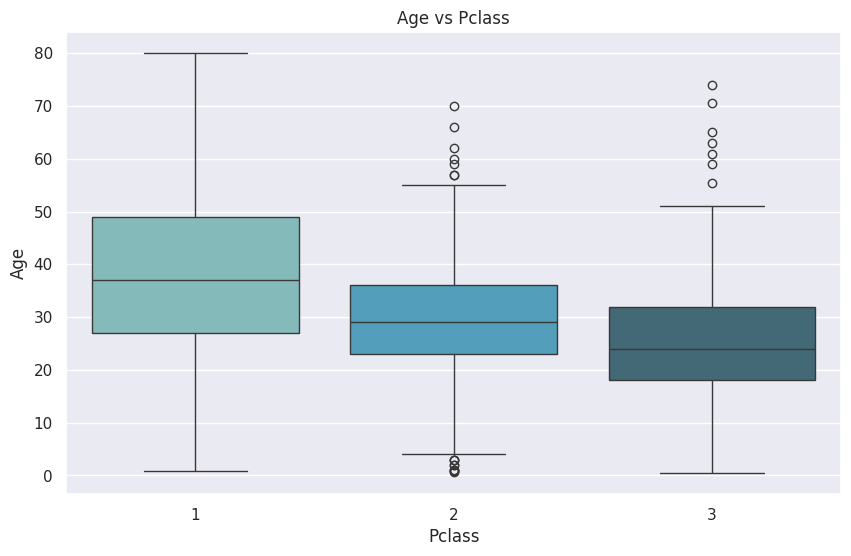

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Pclass", y="Age", data=full_data, palette= 'GnBu_d').set_title('Age vs Pclass')
plt.show()

In [ ]:
#inputation function
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age

# Apply the function to the age group
full_data['Age'] = full_data[['Age', 'Pclass']].apply(impute_age, axis=1)

/tmp/ipykernel_4915/744686885.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
/tmp/ipykernel_4915/744686885.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


In [ ]:
# Remove the cabin feature
full_data.drop('Cabin', axis=1, inplace=True)

In [ ]:
# Remove rows with missing data
full_data.dropna(inplace=True)

In [ ]:
# Numeric summary
full_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.066409,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.244532,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,37.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


he Titanic dataset contains information about passengers aboard the RMS Titanic sinking, including age, gender, ticket class, and survival status. It provides insight into how different factors such as social class and gender influenced survival during the disaster. Analysis shows that women and higher-class passengers had better chances of survival. Overall, the dataset helps in understanding historical patterns and human behavior in emergencies.